<a href="https://colab.research.google.com/github/guru-ppriyan/ml_intern_cognifyz/blob/main/Restaurant_recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [4]:
import os

print(os.listdir())

['.config', 'sample_data']


In [9]:
import pandas as pd

df = pd.read_csv("/content/Dataset  (1).csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [10]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [11]:
# Remove duplicate restaurants
df = df.drop_duplicates()

# Select useful columns for recommendation
recommendation_df = df[
    [
        "Restaurant Name",
        "Cuisines",
        "City",
        "Price range",
        "Aggregate rating",
        "Votes"
    ]
].copy()

print("Dataset after removing duplicates:", recommendation_df.shape)
recommendation_df.head()

Dataset after removing duplicates: (9551, 6)


,Restaurant Name,Cuisines,City,Price range,Aggregate rating,Votes
0,Le Petit Souffle,"French, Japanese, Desserts",Makati City,3,4.8,314
1,Izakaya Kikufuji,Japanese,Makati City,3,4.5,591
2,Heat - Edsa Shangri-La,"Seafood, Asian, Filipino, Indian",Mandaluyong City,4,4.4,270
3,Ooma,"Japanese, Sushi",Mandaluyong City,4,4.9,365
4,Sambo Kojin,"Japanese, Korean",Mandaluyong City,4,4.8,229


In [14]:

recommendation_df["Cuisines"] = (
    recommendation_df["Cuisines"]
    .fillna("Unknown")
    .astype(str)
    .str.lower()
    .str.strip()
)

print("Cuisine data prepared successfully.")
recommendation_df[["Restaurant Name", "Cuisines", "Price range"]].head()

Cuisine data prepared successfully.


,Restaurant Name,Cuisines,Price range
0,Le Petit Souffle,"french, japanese, desserts",3
1,Izakaya Kikufuji,japanese,3
2,Heat - Edsa Shangri-La,"seafood, asian, filipino, indian",4
3,Ooma,"japanese, sushi",4
4,Sambo Kojin,"japanese, korean",4


In [13]:

recommendation_df["content"] = (
    recommendation_df["Cuisines"] + " " +
    recommendation_df["City"].fillna("").astype(str).str.lower() + " " +
    recommendation_df["Price range"].astype(str)
)

print("Content feature created successfully.")
recommendation_df[["Restaurant Name", "content"]].head()

Content feature created successfully.


,Restaurant Name,content
0,Le Petit Souffle,"french, japanese, desserts makati city 3"
1,Izakaya Kikufuji,japanese makati city 3
2,Heat - Edsa Shangri-La,"seafood, asian, filipino, indian mandaluyong c..."
3,Ooma,"japanese, sushi mandaluyong city 4"
4,Sambo Kojin,"japanese, korean mandaluyong city 4"


In [15]:

tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(recommendation_df["content"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9551, 313)


In [16]:

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Cosine similarity matrix shape:", cosine_sim.shape)

Cosine similarity matrix shape: (9551, 9551)


In [17]:
def recommend_restaurants(cuisine, price_range, n=5):
    cuisine = cuisine.lower().strip()

    # Create user preference vector
    user_content = f"{cuisine} {price_range}"
    user_vector = tfidf.transform([user_content])

    # Calculate similarity with all restaurants
    similarity_scores = cosine_similarity(user_vector, tfidf_matrix).flatten()

    # Get top matching restaurants
    top_indices = similarity_scores.argsort()[::-1][:n]

    recommendations = recommendation_df.iloc[top_indices].copy()
    recommendations["Similarity Score"] = similarity_scores[top_indices]

    return recommendations[
        ["Restaurant Name", "Cuisines", "City",
         "Price range", "Aggregate rating", "Similarity Score"]
    ]

In [18]:

cuisine_preference = "North Indian"
price_preference = 2

recommendations = recommend_restaurants(
    cuisine_preference,
    price_preference,
    n=5
)

recommendations

,Restaurant Name,Cuisines,City,Price range,Aggregate rating,Similarity Score
3459,Meatwale.com,"north indian, indian",New Delhi,1,0.0,0.833607
6803,Mahipal Dhaba,north indian,New Delhi,1,2.8,0.764058
2737,Pandit Ji Paranthe Wale,north indian,New Delhi,1,3.7,0.764058
4381,Food Corner,north indian,New Delhi,1,0.0,0.764058
6831,Amor Kitchen,north indian,New Delhi,1,0.0,0.764058


In [19]:

recommended_cuisines = recommendations["Cuisines"].str.lower()

cuisine_match = recommended_cuisines.str.contains(
    cuisine_preference.lower(),
    na=False
).sum()

price_match = (
    recommendations["Price range"] == price_preference
).sum()

print("Recommendation Quality Evaluation")
print("---------------------------------")
print("Total recommendations:", len(recommendations))
print("Cuisine matches:", cuisine_match)
print("Price range matches:", price_match)
print("Average similarity score:",
      round(recommendations["Similarity Score"].mean(), 3))

Recommendation Quality Evaluation
---------------------------------
Total recommendations: 5
Cuisine matches: 5
Price range matches: 0
Average similarity score: 0.778


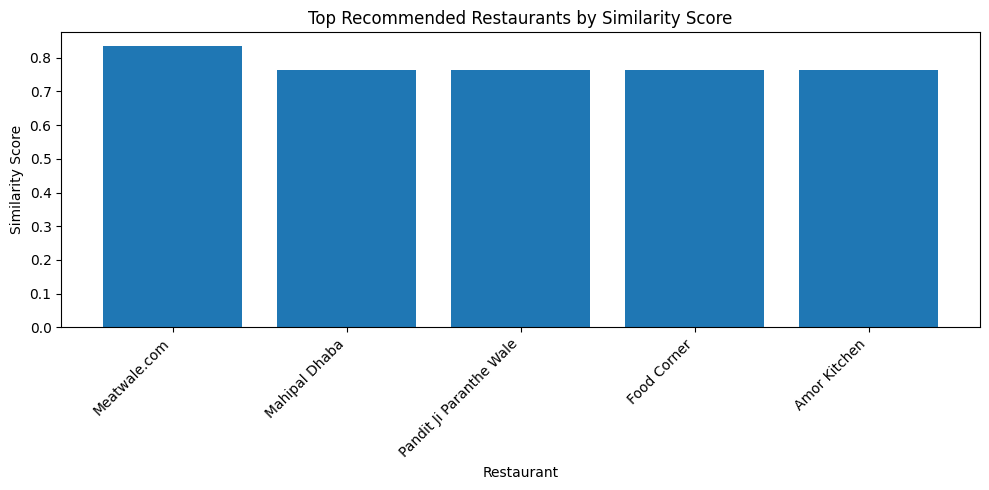

In [20]:


plt.figure(figsize=(10, 5))

plt.bar(
    recommendations["Restaurant Name"],
    recommendations["Similarity Score"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Restaurant")
plt.ylabel("Similarity Score")
plt.title("Top Recommended Restaurants by Similarity Score")
plt.tight_layout()
plt.show()

## Conclusion

A content-based restaurant recommendation system was successfully developed using user preferences such as cuisine and price range. The system uses TF-IDF vectorization and cosine similarity to identify restaurants that are most similar to the user's preferences.

Sample user preferences were tested, and the system generated personalized restaurant recommendations. The recommendations were evaluated based on cuisine matching, price-range matching, and similarity scores.

Overall, the system demonstrates how content-based filtering can be used to provide personalized restaurant recommendations.